In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tools.eval_measures import rmse
import statsmodels.formula.api as smf
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df=pd.read_csv("../data/insurance.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [7]:
dupl = list(df[df.duplicated()==True].index)
print(dupl)
print("Shape Before: ", df.shape)
df.drop(df.index[dupl], inplace=True)
print("Shape After: ", df.shape)

[581]
Shape Before:  (1338, 7)
Shape After:  (1337, 7)


In [9]:
le = LabelEncoder()
# Label encode only binary columns
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

# One-hot encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

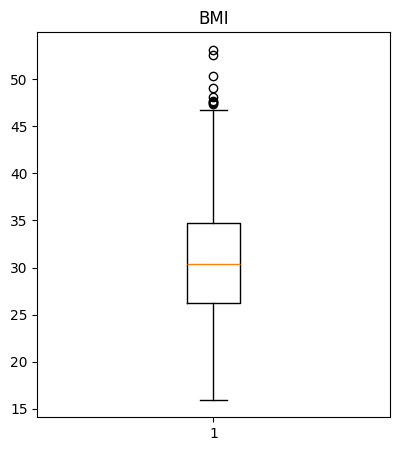

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df['bmi'])
plt.title('BMI')

plt.show()

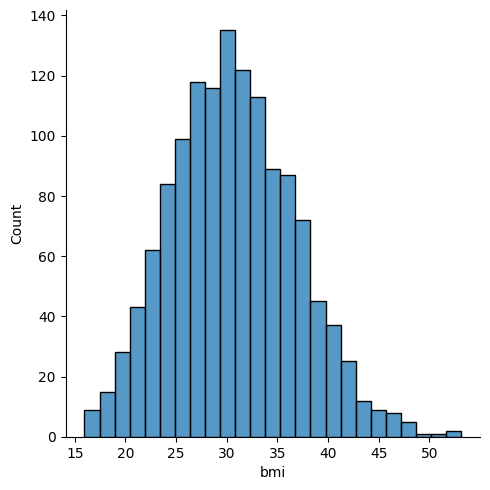

In [17]:
sns.displot(df['bmi'])

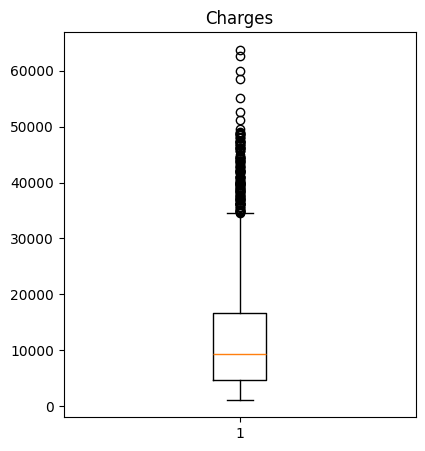

In [18]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df['charges'])
plt.title('Charges')

plt.show()

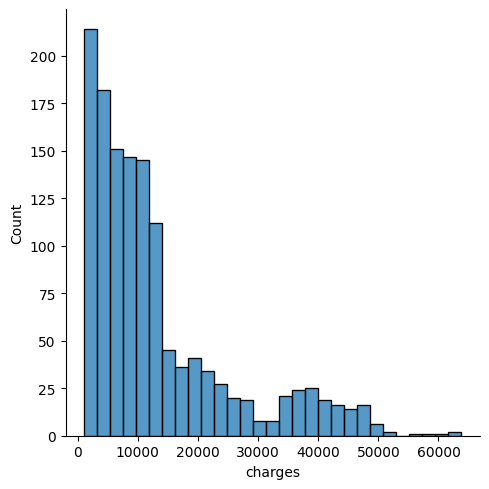

In [19]:
sns.displot(df['charges'])

Z-score is used to quantify the ‘unusualness’ of an observation. A z-score is the number of standard deviations above/below the average. As an example, a z-score of -2 indicates that the observation is two standard deviations away below the average. The further away the observation’s z-score from 0, the more unusual it is. Z-score beyond 3 or below -3 indicates that the observation is an outlier we need to remove (outliers with |z-scores| less than or equal to 3 are not removed). The codes below are used to determine which observation is an outlier by calculating its z-score.

In [20]:
df['z_bmi'] = np.abs(stats.zscore(df['bmi']))
outlBmi = list(np.where(np.abs(df['z_bmi']) > 3)[0])
print("BMI Outliers: ", outlBmi)
print("Total outlier BMI: ", len(outlBmi), "\n")
df['z_charges'] = np.abs(stats.zscore(df['charges']))
outlCharges = list(np.where(np.abs(df['z_charges']) > 3)[0])
print("Charges Outliers: ", outlCharges)
print("Total outlier Charges: ", len(outlCharges))
outl = list(set(outlBmi + outlCharges))

BMI Outliers:  [np.int64(116), np.int64(846), np.int64(1046), np.int64(1316)]
Total outlier BMI:  4 

Charges Outliers:  [np.int64(34), np.int64(543), np.int64(577), np.int64(818), np.int64(1145), np.int64(1229), np.int64(1299)]
Total outlier Charges:  7


In [21]:
df.iloc[outl, :]

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,z_bmi,z_charges
577,31,0,38.095,1,1,58571.07448,False,False,False,1.218649,3.741334
34,28,1,36.400,1,1,51194.55914,False,False,True,0.940697,3.131998
1317,18,1,53.130,0,0,1163.46270,False,True,False,3.684136,1.000812
1230,52,1,34.485,3,1,60021.39897,True,False,False,0.626670,3.861138
847,23,1,50.380,1,0,2438.05520,False,True,False,3.233182,0.895524
819,33,0,35.530,0,1,55135.40209,True,False,False,0.798032,3.457531
1300,45,1,30.360,0,1,62592.87309,False,True,False,0.049761,4.073554
116,58,1,49.060,0,0,11381.32540,False,True,False,3.016724,0.156767
1047,22,1,52.580,1,1,44501.39820,False,True,False,3.593945,2.579111
1146,60,1,32.800,0,1,52590.82939,False,False,True,0.350358,3.247337


In [22]:
print(df.shape)
df.drop(df.index[list(outl)], inplace=True)
print(df.shape)

(1337, 11)
(1326, 11)


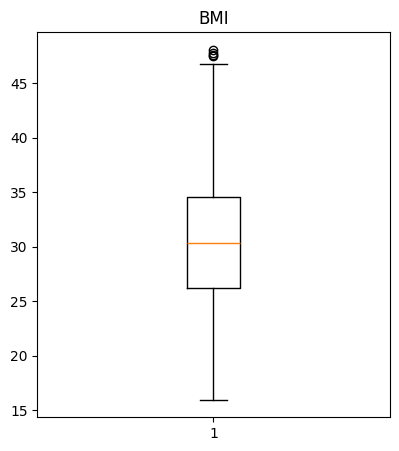

In [23]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df['bmi'])
plt.title('BMI')

plt.show()

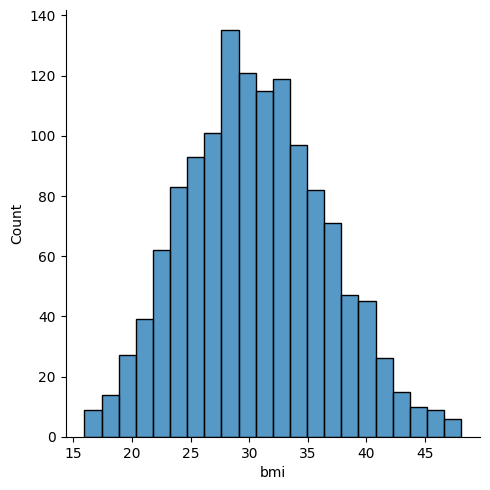

In [24]:
sns.displot(df['bmi'])

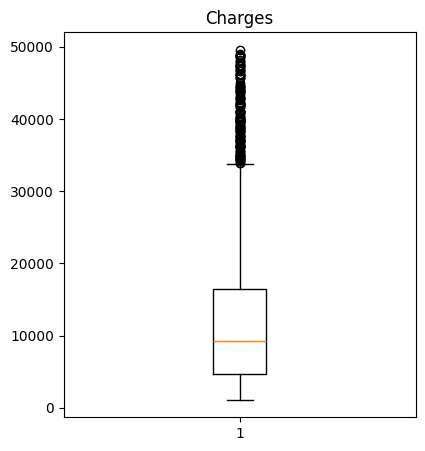

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(df['charges'])
plt.title('Charges')

plt.show()

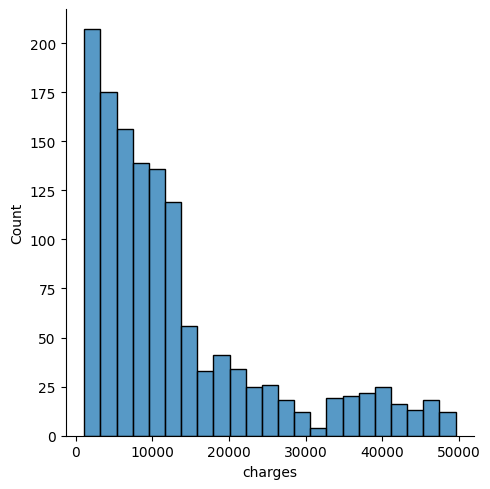

In [26]:
sns.displot(df['charges'])

In [27]:
df.describe(include='all')

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,z_bmi,z_charges
count,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326,1326,1326,1326.000000,1326.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1004,968,1003,NaN,NaN
mean,39.227753,0.503017,30.570743,1.099548,0.200603,13039.837572,NaN,NaN,NaN,0.795150,0.734449
std,14.037019,0.500180,5.992764,1.207167,0.400603,11677.031551,NaN,NaN,NaN,0.577247,0.625285
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900,NaN,NaN,NaN,0.003534,0.004153
25%,27.000000,0.000000,26.220000,0.000000,0.000000,4740.287150,NaN,NaN,NaN,0.333960,0.314147
50%,39.000000,1.000000,30.300000,1.000000,0.000000,9303.297725,NaN,NaN,NaN,0.689393,0.620531
75%,51.000000,1.000000,34.560000,2.000000,0.000000,16389.832412,NaN,NaN,NaN,1.149268,0.910357


Text(0.5, 1.0, 'Correlation Between Variables')

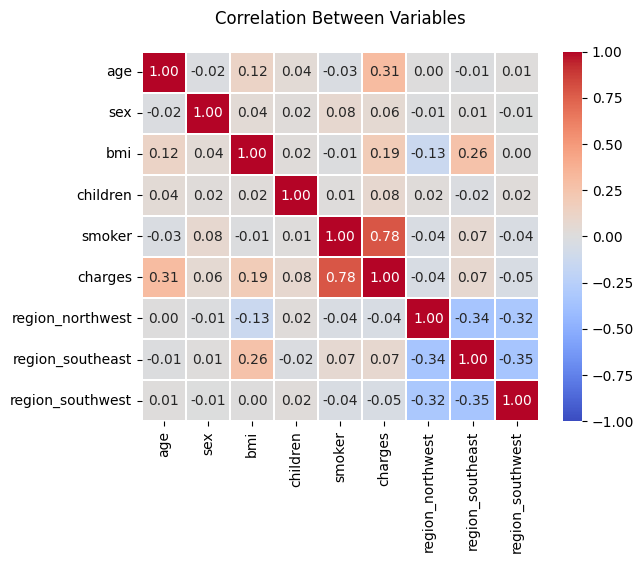

In [28]:
df = df.drop(columns=['z_bmi', 'z_charges'])
corr = df.corr()
sns.heatmap(corr, vmin=-1, vmax=1, cmap = 'coolwarm', annot=True, fmt='.2f', linewidths=0.1)
plt.title("Correlation Between Variables", pad=20)

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['bmi','age','smoker']]  # features only (no target ideally)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

# 🔥 Interpretation:
    # VIF=1/1-r*2
# 	•	VIF = 1 → no correlation
# 	•	VIF > 5 → moderate problem
# 	•	VIF > 10 → serious multicollinearity

  feature       VIF
0     bmi  7.774034
1     age  7.576135
2  smoker  1.237905


In [30]:
df1 = df[['age', 'bmi', 'smoker', 'charges']]

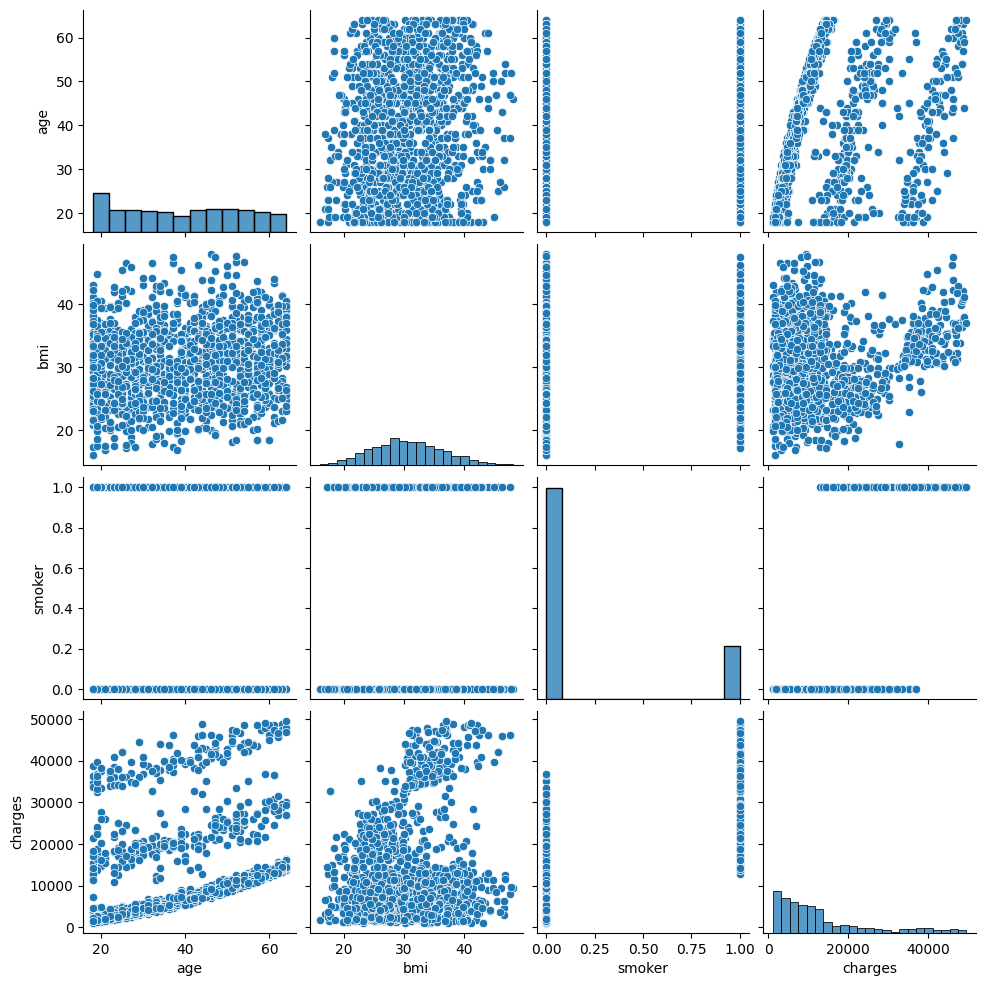

In [31]:
sns.pairplot(df1)

In [32]:
targets = df1['charges']
inputs = df1.drop(['charges'],axis=1)

In [34]:
inputs.head()

,age,bmi,smoker
0,19,27.900,1
1,18,33.770,0
2,28,33.000,0
3,33,22.705,0
4,32,28.880,0


In [35]:
targets.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [36]:
# Import the module for the split
from sklearn.model_selection import train_test_split

# Spliting the variables with an 80-20 split and some random state
# random state(with any integer), makes the split same everytime we run the code. without it, we get different 
# splits every time we run the code. so You are not removing randomness — you are controlling it
x_train, x_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=365)

In [37]:
# Create a linear regression object
reg = LinearRegression()
# Fit the regression with the scaled TRAIN inputs and targets
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
# Checking the outputs of the regression
y_hat = reg.predict(x_train)

In [42]:
y_hat

array([10189.29283753, 33950.5185326 ,  8335.44113949, ...,
        5024.68206494, 11951.83951757, 34236.57400006], shape=(1060,))

In [43]:
y_train

907      7633.72060
1053    25309.48900
988      4518.82625
786     12741.16745
686      7729.64575
           ...     
263     36219.40545
430     23082.95533
866      1141.44510
806     28476.73499
697     40273.64550
Name: charges, Length: 1060, dtype: float64

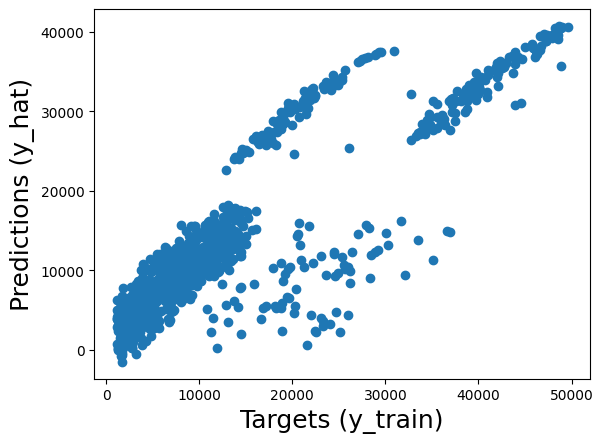

In [46]:
# Comparing the targets (y_train) and the predictions (y_hat)
plt.scatter(y_train, y_hat)
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
plt.show()

In [47]:
res=y_train - y_hat
res

# 🔍 What residuals mean

# For each data point:
# 	•	Positive residual
            # → actual > predicted
            # → model underestimated
# 	•	Negative residual
            # → predicted > actual
            # → model overestimated

907     -2555.572238
1053    -8641.029533
988     -3816.614889
786     -2981.392639
686       -34.824239
            ...     
263      7270.005345
430     19089.119575
866     -3883.236965
806     16524.895472
697      6037.071500
Name: charges, Length: 1060, dtype: float64

Text(0.5, 1.0, 'Residuals PDF')

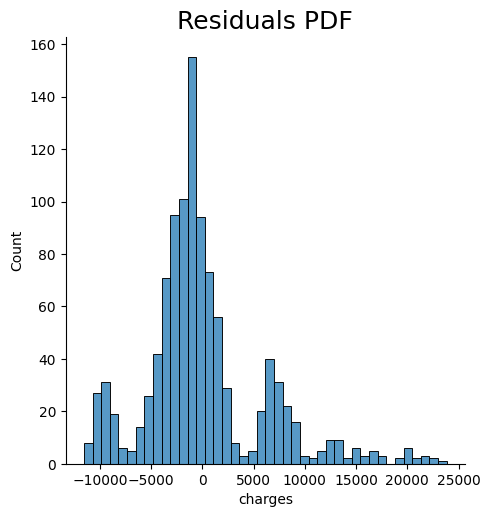

In [48]:
sns.displot(y_train - y_hat)

plt.title("Residuals PDF", size=18)

In [49]:
score =reg.score(x_train,y_train)
intercept =reg.intercept_
coefficents =reg.coef_
print("Score: ",score)
print("Intercept: ",intercept)
print("Coefficents: ",coefficents)

# Score is the r squared
# intercept is the y value when all x is 0
# since we scaled the data, “How much y changes for a 1 standard deviation increase in the feature”

Score:  0.759741709419002
Intercept:  -11067.23463967232
Coefficents:  [  257.16326929   307.40085432 23770.53405717]


In [58]:
scores = []
rmse_list = []

lrmodel = LinearRegression()
cv = KFold(n_splits=10, random_state=42, shuffle=True)

for train_index, test_index in cv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    lrmodel.fit(X_train, y_train)
    y_predict = lrmodel.predict(X_test)

    scores.append(lrmodel.score(X_test, y_test))
    rmse_fold = rmse(y_test, y_predict)
    rmse_list.append(rmse_fold)

<b><h2 >Even though you’re using the same lrmodel object, When you call .fit(...), it overwrites all learned parameters (coefficients, intercept), does not remember previous training,	starts fresh every time</h2></b>

In [60]:
lm = smf.ols(formula='charges ~ age + bmi + smoker', data = df1).fit()
comparison = pd.DataFrame({"y_test": y_test, "y_predict": y_predict})
print("Summary: ", lm.summary())
print("R Squared Mean: ", np.mean(scores))
print("RMSE mean: ", np.mean(rmse_list))

Summary:                              OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     1313.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:32:17   Log-Likelihood:                -13384.
No. Observations:                1326   AIC:                         2.678e+04
Df Residuals:                    1322   BIC:                         2.680e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.118e+04    914.389    -12.22